<a href="https://colab.research.google.com/github/GustavoGarcia627/Analisis-num-rico---Famaf/blob/main/2026_Practico_3_numerico_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis numérico 1 - 2026
#Trabajo de Laboratorio Nº 3

**Ejercicio 1:** Programar una función en `python` que evalúe el polinomio interpolante $p$ usando la forma de Lagrange. La función debe llamarse "`ilagrange`" y tener como entrada (x,y,z) donde $x,y \in \mathbb{R}^n$ son las coordenadas de los pares a interpolar ( o sea $p(x_i) = y_i, \, i = 1, \dots n)$ y $z \in \mathbb{R}^m$ son los valores para evaluar $p$. La salida debe ser $w \in \mathbb{R}^m $ tal que $w_j = p(z_j)$, $j = 1, \dots, m.$ La sintaxis a utilizar debe ser:


```
>>> w = ilagrange(x,y,z)
```



In [1]:
#Ejercicio 1
def ilagrange(x:list,y:list,z:list)->list:
  '''
  Pre: x,y pares a interpolar. z valor al evaluar p en x_i
  Pos: Devuelve w valores del polinomio evaluado
  '''
  w = []
  sum = 0
  li= 1
  for l in range(0,len(z)):
    for i in range(0,len(x)):
      for j in range(0,len(x)):
        if i!=j:
          #Polinomio de lagrange evaluado
          li *= ((z[l]-x[j])/(x[i]-x[j]))
      #Suma los resultados
      sum+=y[i]*li
      li = 1
    #agrega a la lista de resultados
    w.append(sum)
    sum = 0
  return w

In [2]:
#Probamos el método
x = [1,2,3]
y = [9,34,2]
z = [3,2,1]
print(ilagrange(x,y,z))

[2.0, 34.0, 9.0]


**Ejercicio 2:** Realizar una función en `python` análoga al ejercicio 1 pero utilizando la forma de Newton del polinomio interpolante, calculando los coeficientes mediante *diferencia divididas.*

La función debe llamarse "`inewton`"

In [3]:
def inewton(x:list, y:list, z:list)->list:
    n = len(x)
    w = []

    # 1. Tabla de Diferencias Divididas
    c = [[0.0]*n for _ in range(n)]
    for i in range(n):
        c[i][0] = y[i]

    for j in range(1, n):
        for i in range(0, n - j):
            c[i][j] = (c[i+1][j-1] - c[i][j-1]) / (x[i+j] - x[i])

    # 2. Evaluación para cada punto en z
    for valor_z in z: # Recorremos cada valor de la lista z
        resultado = c[0][0]
        producto_x = 1.0
        for j in range(1, n):
            producto_x *= (valor_z - x[j-1])
            resultado += c[0][j] * producto_x
        w.append(resultado)

    return w

In [4]:
#Probando el método
x = [1,2,3]
y = [9,34,2]
z = [3,2,1]
print(inewton(x,y,z))

[2.0, 34.0, 9.0]


**Ejercicio 3:** Considerar la función $f$ tal que $f(x) = 1/x$. Utilizando el ejercicio anterior, graficar en una misma figura $f$ y $p$ que interpole $\{(\ i,f(i) \ )\}_{i=1}^5$, usando para ambas los puntos equiespaciados $z_j= 24/25+j/25, \ j=1, \dots, 101$.

In [5]:
#Importamos la libreria:
import matplotlib.pyplot as plt

In [6]:
def f(x):
  return 1/x

In [7]:
#Conseguimos el par (x,f(x))
hx = [] #Valores de xi
hf = [] #Valores de f(xi)
zx = [] #i's de la sucesión
zp = [] #f(zi)
for j in range(1,101+1):
  x = 24/25 + j/25
  hx.append(x)
  hf.append(f(x))

for i in range(1,6):
  zx.append(i)
  zp.append(f(i))
#Conseguimos puntos evaluados en el
#polinomio interpolante obtenido.
px = ilagrange(zx,zp,hx)

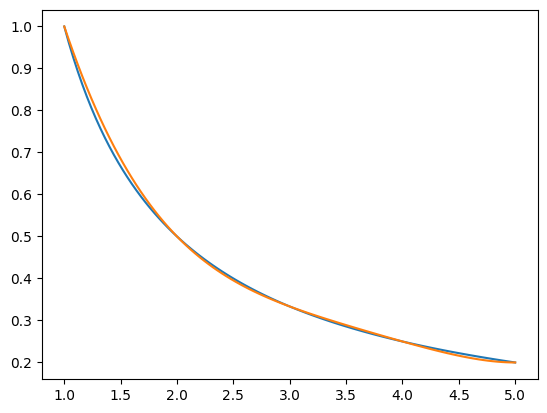

In [8]:
plt.plot(hx,hf) #f(x)
plt.plot(hx,px) #pn(x)

**Ejercicio 4:** El polinomio interpolante se puede ver afectado por el conjunto de puntos elegidos. Considerar la función $f$ tal que


$$f(x)=\frac{1}{1+25x^2}$$



Graficar $f,p_n$ y $q_n$ en una misma figura usando 200 puntos igualmente espaciados en el intervalo $[-1,1]$ donde:

**(a)** $p_n$ es el polinomio que interpola los pares $\{(x_i,f(x_i))\}_{i=1}^{n+1}$ con


$$x_i = \frac{2(i-1)}{n}-1,$$


para $i=1,\dots, n+1.$

**(b)** $q_n$ es el polinomio que interpola los pares $\{(x_i,f(x_i))\}_{i=0}^{n}$ con


$$x_i = \cos\left(\frac{2i+1}{2n+2^\pi}\right),$$


para $i = 0 , \dots, n$. Estos puntos son conocidos como nodos de Tchebychev

Varie $n$ entre 1 y 15. Implementar la resolución de este ejercicio en el `script` *"lab3ej4"*.

Al ejecutarlo debe mostrar 15 gráficos

In [9]:
import numpy as np

In [10]:
def f4(x):
  return (1/(1+25*(x**2)))

In [11]:
#200 Puntos equiespaciados en el intervalo [-1,1]
hx = np.linspace(-1,1,200)
hf = []
#Definimos los valores de fx
for i in hx:
  hf.append(f4(i))

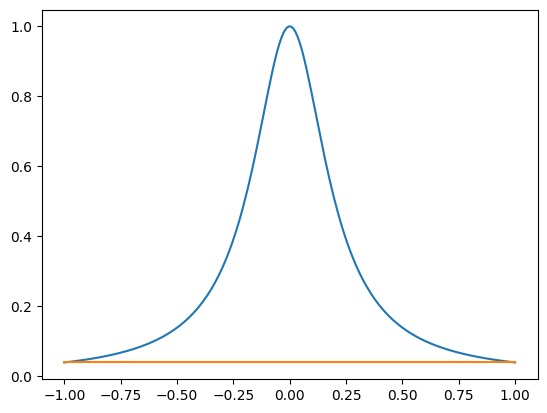

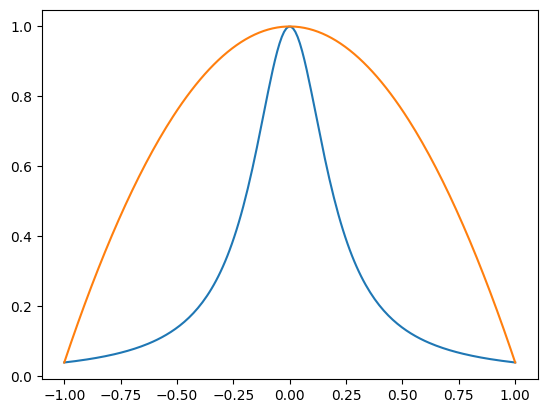

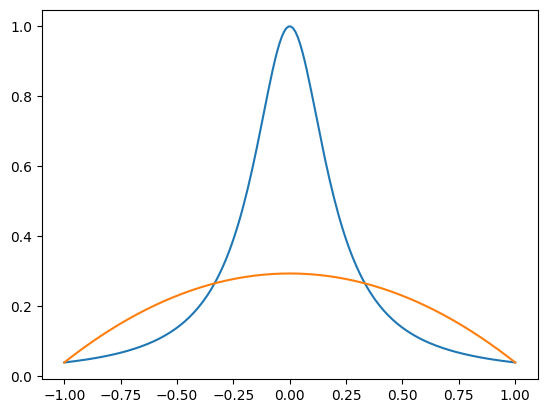

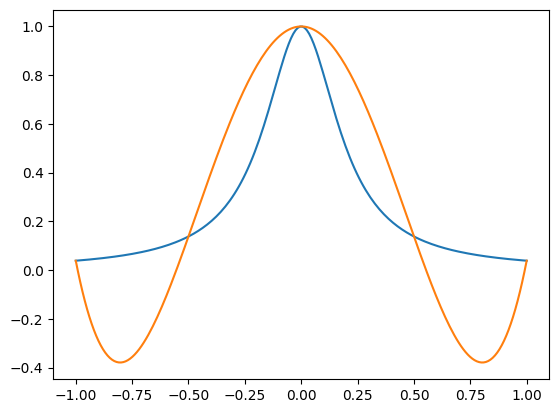

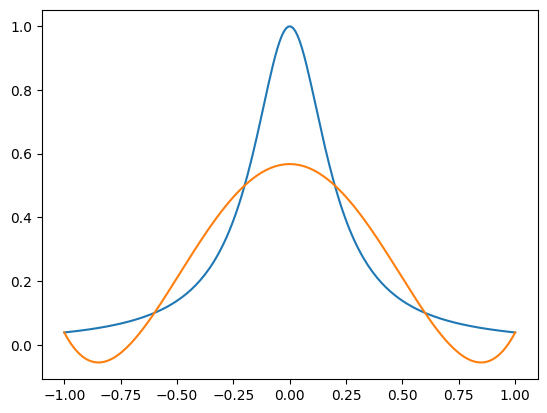

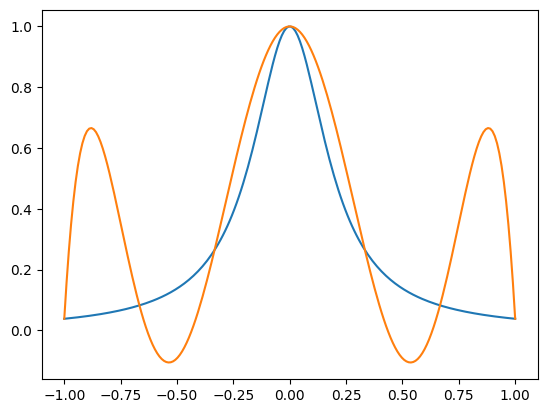

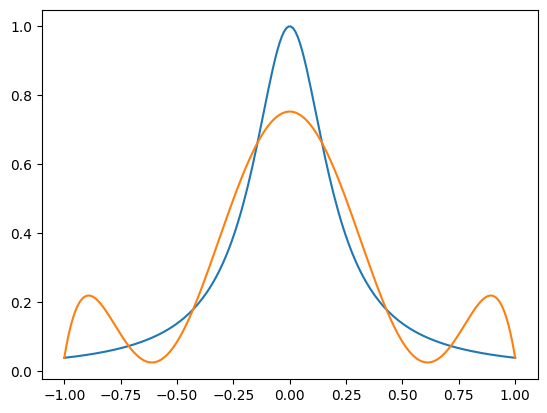

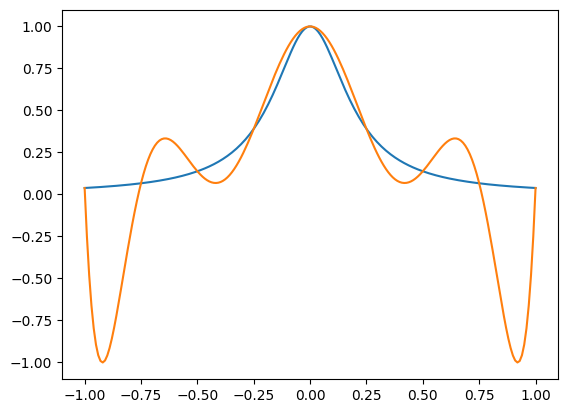

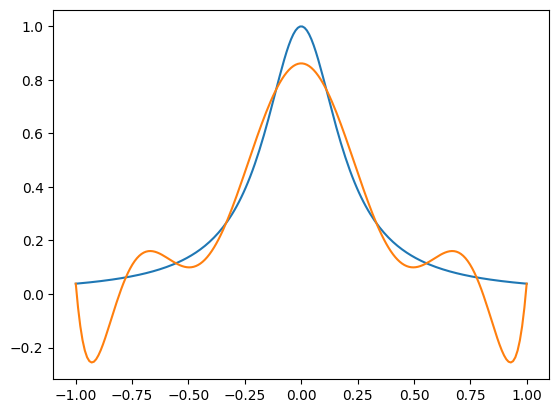

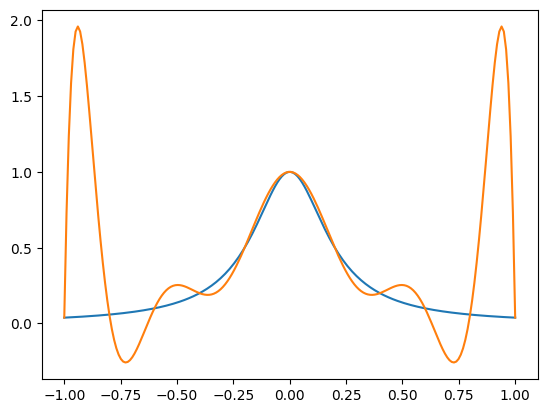

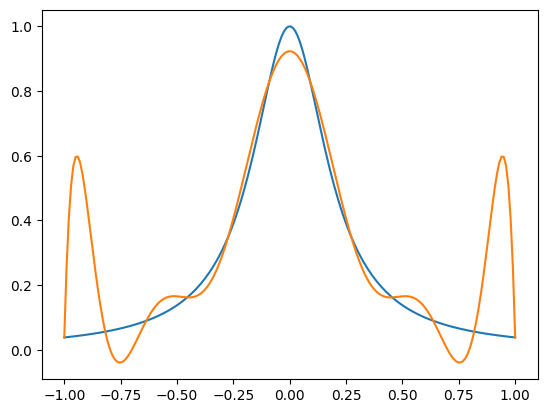

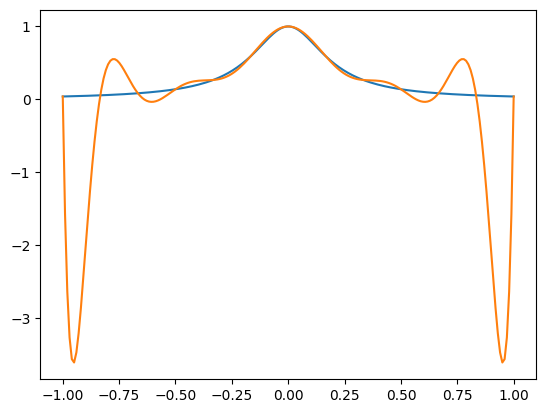

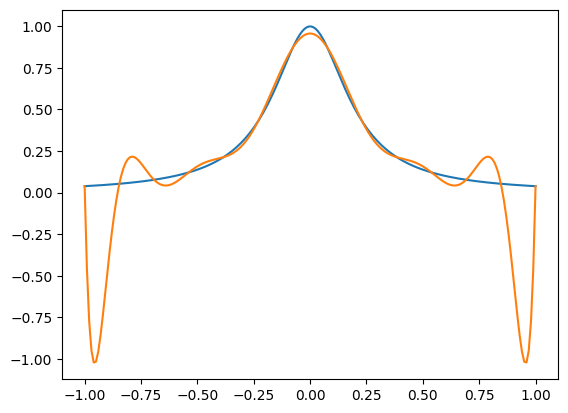

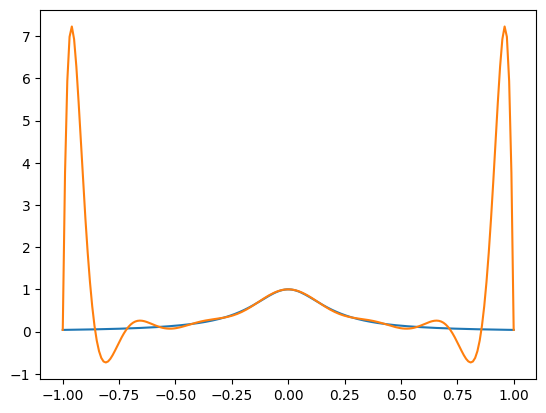

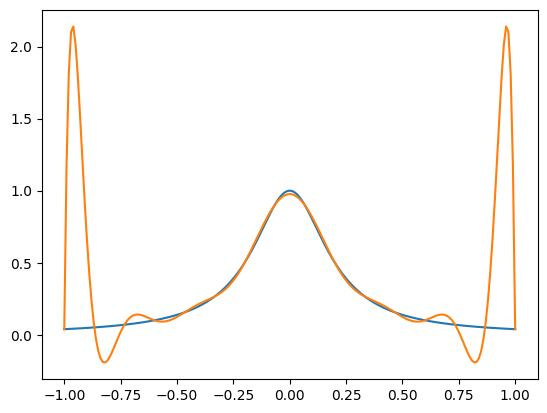

<Figure size 640x480 with 0 Axes>

In [12]:
for n in range(1,16):
  #Polinomio interpolante p
  px = []
  pf = []

  for i in range(1,n+2):
    xi = ((2*(i-1))/n)-1
    px.append(xi)
    pf.append(f4(xi))
  pn = ilagrange(px,pf,hx)
  plt.plot(hx,hf)
  plt.plot(hx,pn)
  plt.figure()

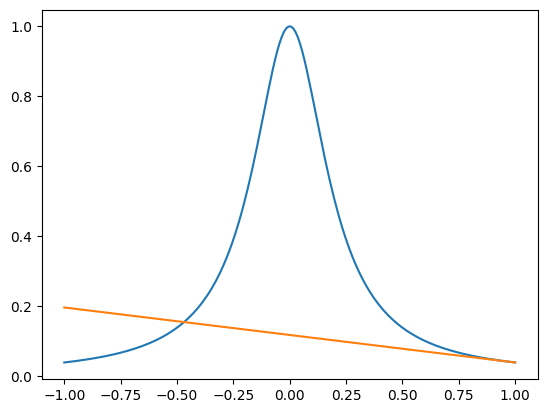

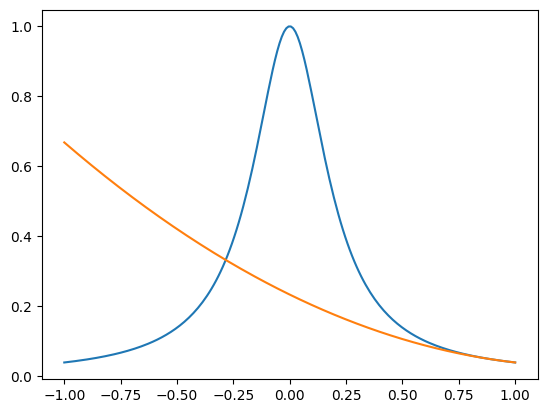

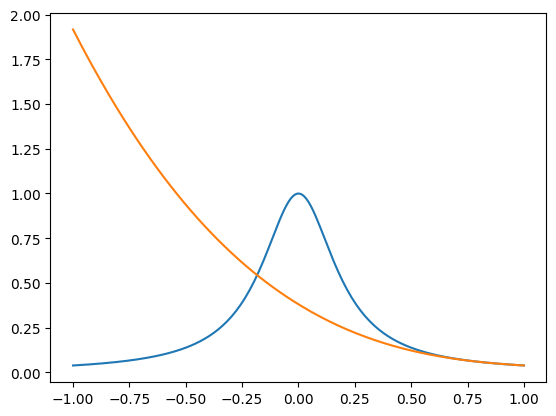

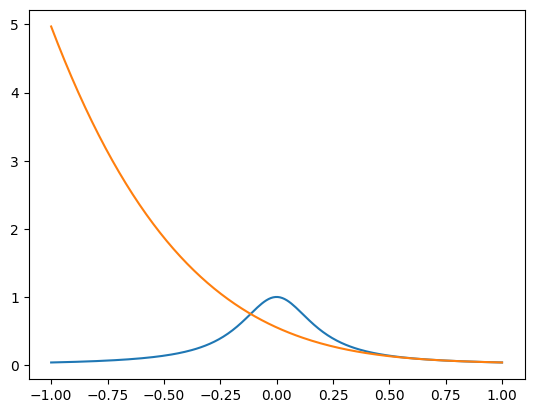

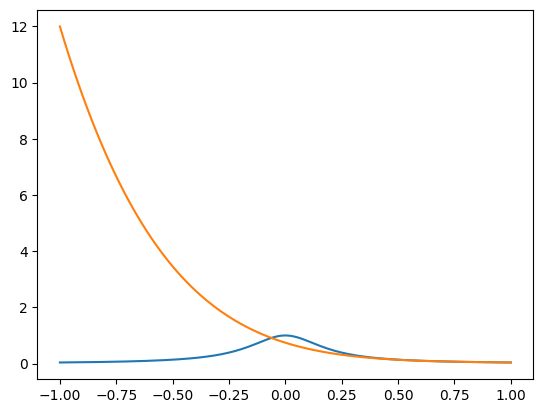

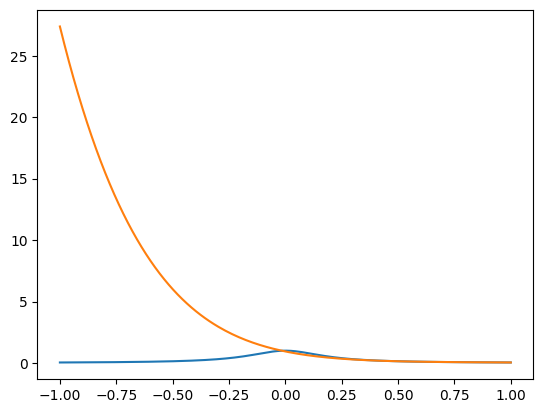

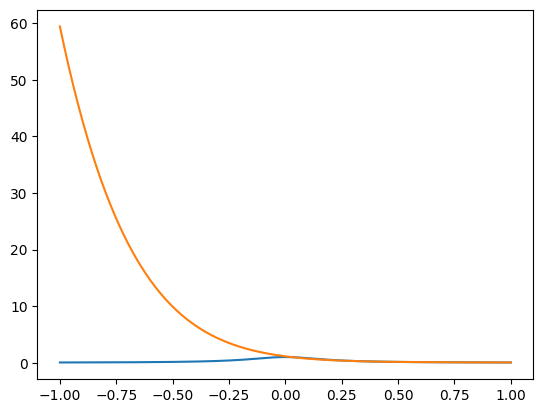

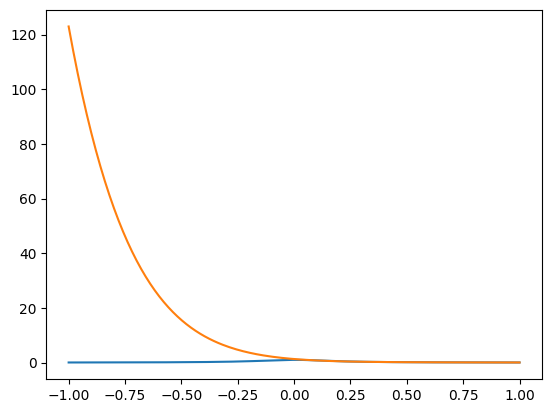

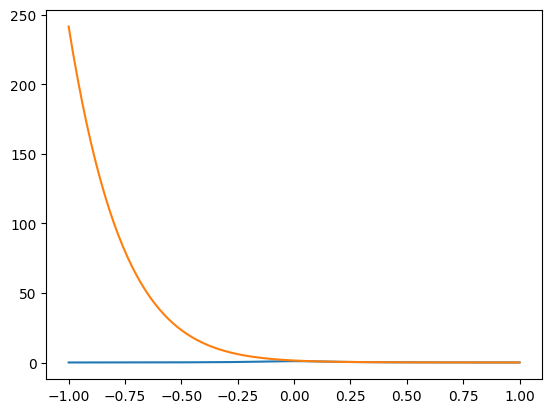

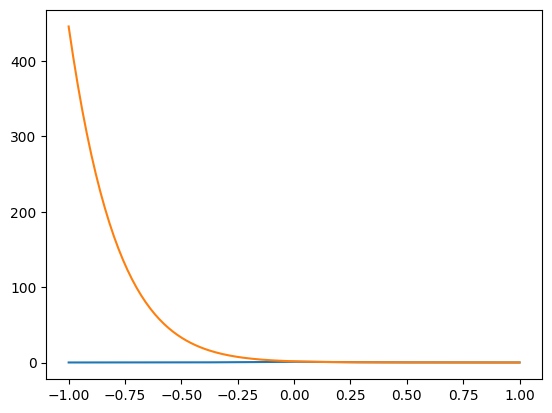

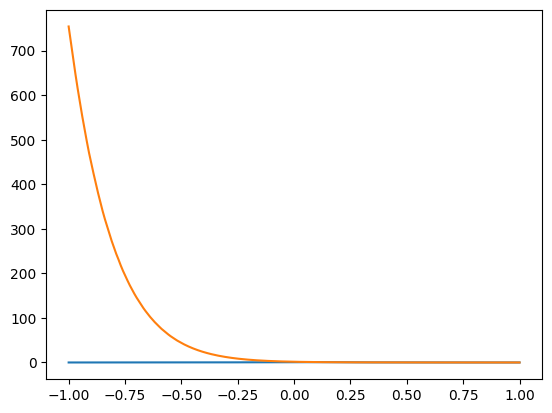

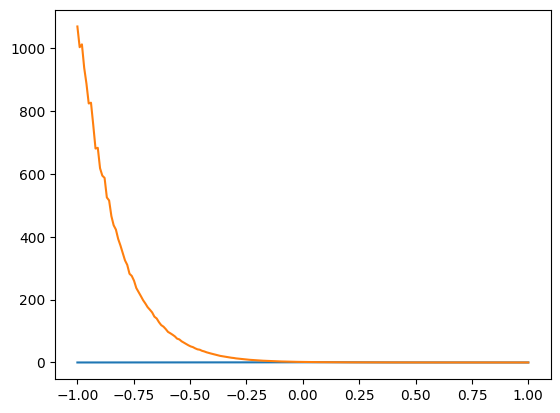

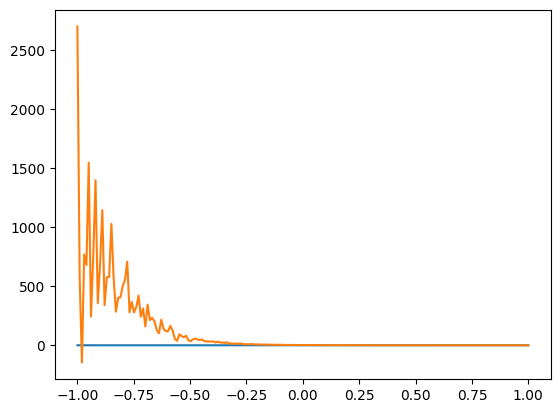

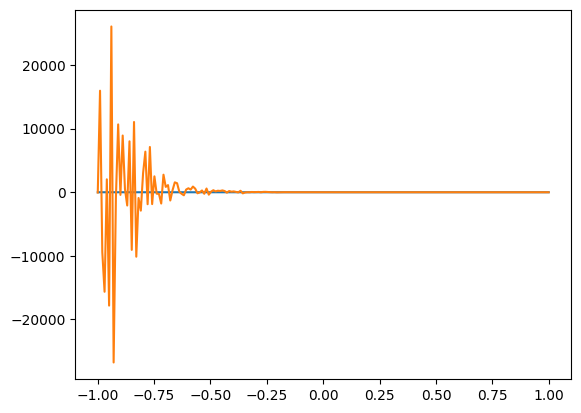

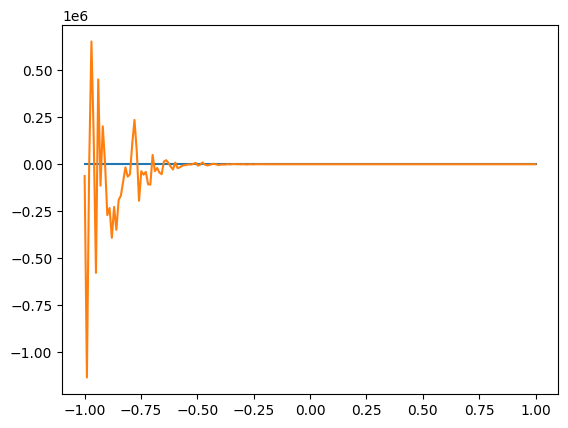

<Figure size 640x480 with 0 Axes>

In [13]:
#Ejercicio b completo:
for n in range(1,16):
  qx = []
  qf = []

  for i in range(n+1):
    xi = np.cos(((2*i)+1)/((2*n) + 2**np.pi))
    qx.append(xi)
    qf.append(f4(xi))
  qn = ilagrange(qx,qf,hx)
  plt.plot(hx,hf)
  plt.plot(hx,qn)
  plt.figure()

**Ejercicio 5:** Leer cómo utilizar la función "`interpd1`" del paquete "`scipy.interpolate`" de python en la pagina  https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html

El archivo de `datos_aeroCBA.dat` contiene una matriz con los datos de la página
https://www.tutiempo.net/clima/ws-873440.html

Cargar la matriz de datos en **python** usando `np.loadtxt` y extraer los datos existentes de temperatura media anual registrados en el Aeropuerto de Córdoba. Mediante un spline cúbico estimar los valores faltantes y graficar.

**Observación:** en algunos casos será necesario extrapolar.

Implementar la resolución de este ejercicio en el **script** "`lab3ej5`", que realice el gráfico y devuelva los valores de temperatura media para TODOS los años entre 1957 y 2017

Considerar los valores importados de la tabla siguiente: https://www.tutiempo.net/clima/descargar/info/

In [14]:
from scipy import interpolate

In [15]:
def lab3ej5(datos):
  '''
  Pre: Recibe datos del clima desde 1957 a 2015
  Pos: Devuelve un gráfico y valor de temperatura en los años
  '''
  x=[] #Valor de los años
  y=[] #Valor de la temperatura media anual
  valores_final = [] #Valores de temperaturas con puntos inter o extrapolados
  for i in datos:
    if not(np.isnan(i[1])):
      x.append(i[0])
      y.append(i[1])
  f = interpolate.interp1d(x, y,"cubic",fill_value="extrapolate")
  xnew = np.arange(1957, 2017, 1)
  ynew = f(xnew)   # use interpolation function returned by `interp1d`
  plt.plot(x, y, 'o', xnew, ynew, '-')
  plt.show()

  for z in range(1957,2017):
    valores_final.append([z,(f(z))])

  return valores_final

In [22]:
#Importo los valores del archivo
nArchivo = "datos_aeroCBA.dat"
dArchivo = np.loadtxt(nArchivo)
lab3ej5(dArchivo)

FileNotFoundError: datos_aeroCBA.dat not found.

**Ejercicio 6** Consideremos la siguiente tabla de datos:
$$\begin{matrix}
x &-3& -2 & -1 & 0 & 1 & 2 & 3 \\
f &1 & 2 & 5 & 10 & 5 & 2 & 1
\end{matrix}$$

Interpolar la tabla utilizando los métodos de Lagrange, Newton y de la función `interp1d`, luego graficar los 3 polinomios juntos. ¿Cuál polinomio parece más suave?

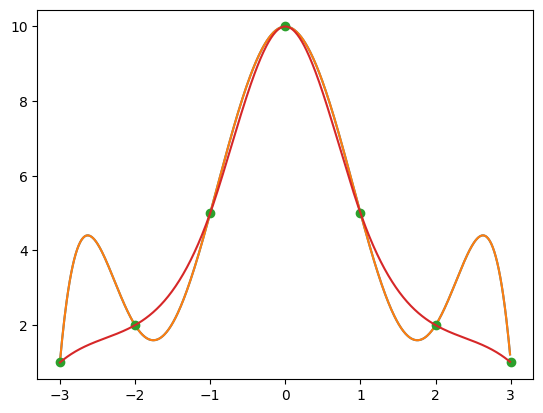

In [21]:
#Ejercicio 6
x = [-3,-2,-1,0,1,2,3]
y = [1,2,5,10,5,2,1]
z = np.arange(-3,3,0.01)

il = ilagrange(x,y,z)
intwn = inewton(x,y,z)

f = interpolate.interp1d(x, y,"cubic",fill_value="extrapolate")
ynew = (f(z))


#plt.plot(x,y)
plt.plot(z,il)
plt.plot(z,intwn)
plt.plot(x, y, 'o', z, ynew, '-')

Los polinomio de lagrange y Newton se superponen en la gráfica. Además el spline tiende a tener una gráfica más suave en comparación a los demás y el fenómeno de Runge no está tan presente

**Ejercicio 7:** Escriba una función `rinterp(fun,x0,x1,err,mit)` que encuentre un cero de la función `fun`de la siguiente forma.

 En cada paso, sea $q_2$ el polinomio interpolante cuadrático de los puntos $(x_{n-1}, f(x_{n-2})), (x_{n-1}, f(x_{n-1}))$ y $(x_n, f(x_n))$. Elegir como $x_{n+1}$ al cero de $q_2$ que esté más cerca de $x_n$. Comparar su perfomance con los métodos para encontrar raíces del laboratorio 2.

In [20]:
#Ejercicio 7
def encontrar_raiz_cercana(a, b, c, x_actual):
    """
    Función auxiliar: Calcula las dos raíces de ax^2 + bx + c
    y devuelve la que esté más cerca de x_actual.
    """
    # Usamos +0j para permitir raíces complejas sin que Python explote
    discriminante = (b**2 - 4*a*c) + 0j
    raiz_disc = np.sqrt(discriminante)

    # Las dos soluciones de la cuadrática
    r1 = (-b + raiz_disc) / (2 * a)
    r2 = (-b - raiz_disc) / (2 * a)

    # Elegimos la que tenga menor distancia al punto actual
    if abs(r1 - x_actual) < abs(r2 - x_actual):
        return r1
    else:
        return r2

def rinterp(fun, x0, x1, err, mit):
    # Müller necesita 3 puntos. Como recibimos 2, generamos el tercero (punto medio)
    x2 = (x0 + x1) / 2

    for i in range(mit):
        # 1. Definimos los puntos actuales para la parábola
        xs = [x0, x1, x2]
        ys = [fun(x) for x in xs]

        # 2. Obtenemos coeficientes a, b, c de la parábola (q2)
        # np.polyfit devuelve [a, b, c] para ax^2 + bx + c
        a, b, c = np.polyfit(xs, ys, 2)

        # 3. Buscamos el cero de q2 más cercano al último punto (x2)
        x3 = encontrar_raiz_cercana(a, b, c, x2)

        # 4. ¿Ya estamos suficientemente cerca? (Criterio de parada)
        # Usamos .real por si x3 terminó siendo algo como (0.693 + 0j)
        if abs(fun(x3.real)) < err:
            return x3.real

        # 5. Actualizamos los puntos para la siguiente iteración
        # Desplazamos: x0 recibe a x1, x1 recibe a x2, y x2 recibe al nuevo x3
        x0, x1, x2 = x1, x2, x3.real

    return x2 # Si llega al límite de iteraciones, devuelve lo último que halló

In [18]:
# --- EJEMPLO DE USO ---
# Definimos la función f(x) = e^x - 2
def mi_funcion(x):
    return np.exp(x) - 2

# Buscamos la raíz empezando en 0 y 1
raiz = rinterp(mi_funcion, x0=0, x1=1, err=1e-5, mit=100)

print(f"La raíz encontrada es: {raiz}")

La raíz encontrada es: 0.6931471912688225
